# Model Comparison: Bayesian NNGP vs Bayesian Linear — Boston Area

Fits two models on Boston-area ZIPs (MA, lat 42.0–42.7, lon -72.0 to -70.5, ~236 ZIPs):
- **Spatial**: Bayesian NNGP (Vecchia/Matern-3/2) + covariates (no state FEs — single state)
- **Linear**: Bayesian linear regression, same covariates, no GP term

Two evaluation schemes:
1. **Within-year**: train on 80% of 2022 ZIPs, test on held-out 20%
2. **Cross-year**: train on all 2020 ZIPs, test on 2022 ZIPs

In [1]:
import sys
sys.path.insert(0, '../milestone4')

import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree
from pyproj import Transformer

from vecchia_spatial_regression import (
    build_model_data, fit_model, save_model_data, load_model_data,
    train_test_split, kernel_np, FULL_US_COVARIATES, lonlat_to_km,
)

/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [2]:
df_full = pd.read_csv('zip_data_full.csv')
print(f'Loaded {len(df_full)} ZIP codes, {df_full["state"].nunique()} states')

# Filter to Boston area (MA ZIPs)
df = df_full[
    (df_full['lat'] >= 42.0) & (df_full['lat'] <= 42.7) &
    (df_full['lon'] >= -72.0) & (df_full['lon'] <= -70.5)
].copy().reset_index(drop=True)
print(f'Boston-area ZIPs: {len(df)}, states: {df["state"].unique()}')
df.head()

Loaded 15776 ZIP codes, 50 states
Boston-area ZIPs: 236, states: <StringArray>
['MA']
Length: 1, dtype: str


,ZIP_CODE,LOG_TRANSACTION_AMT_2020,LOG_TRANSACTION_AMT_2022,lat,lon,prop_college_degree_or_higher_18plus,log_income,log_population,log_contrib_2020,log_contrib_2022,election_2020,election_2022,election_diff,state
0,1420,7.712444,7.086738,42.5796,-71.8031,0.217718,11.195196,10.643995,7.712444,7.086738,1,0,-1,MA
1,1430,7.673688,5.986452,42.6496,-71.9267,0.395842,11.684211,8.748781,7.673688,5.986452,1,0,-1,MA
2,1432,7.273093,7.871311,42.5591,-71.5788,0.386283,11.532395,9.014447,7.273093,7.871311,1,0,-1,MA
3,1434,8.113726,6.976348,42.5385,-71.6115,0.186327,11.996234,7.409742,8.113726,6.976348,1,0,-1,MA
4,1440,7.398174,6.685861,42.5740,-71.9898,0.232715,11.118994,9.979383,7.398174,6.685861,1,0,-1,MA


In [3]:
COVARIATES = tuple(c for c in FULL_US_COVARIATES if c != 'election_diff')  # (prop_college_degree, log_contrib_2020, log_income, log_population)
M_NEIGHBORS = 15
SAMPLE_N = None   # 236 ZIPs — small enough to use all of them
DRAWS = 1000
TUNE  = 1000
CHAINS = 4
CORES  = 4
SEED   = 305
STATE_FES = False  # single state (MA), no state fixed effects

---
## Scheme 1: Within-year (80/20 split on 2022)

In [4]:
# zip_data_full already has log_contrib_2022 as the outcome column
# vecchia_spatial_regression expects 'log_contrib_2022' as the outcome
train_df, test_df = train_test_split(df, frac=0.8, seed=SEED)
print(f'Within-year — Train: {len(train_df)}, Test: {len(test_df)}')

Within-year — Train: 189, Test: 47


### 1A: Bayesian Linear (within-year)

In [5]:
WY_LINEAR_TRACE = Path('boston_trace_wy_linear.nc')
WY_LINEAR_MD    = Path('boston_trace_wy_linear_model_data.npz')

if not WY_LINEAR_TRACE.exists():
    print('Fitting within-year Bayesian linear model...')
    wy_linear_data = build_model_data(
        train_df, covariates=COVARIATES, sample_n=None, m=1,
        seed=SEED, state_fixed_effects=STATE_FES,
    )
    idata_wy_linear = fit_model(
        wy_linear_data, spatial=False,
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
        target_accept=0.9, beta_sigma=5.0, seed=SEED,
    )
    az.to_netcdf(idata_wy_linear, WY_LINEAR_TRACE)
    save_model_data(WY_LINEAR_MD, wy_linear_data)
else:
    print('Loading saved within-year linear trace...')
    idata_wy_linear = az.from_netcdf(WY_LINEAR_TRACE)
    wy_linear_data  = load_model_data(WY_LINEAR_MD)

print(az.summary(idata_wy_linear, var_names=['beta', 'tau2']))

Loading saved within-year linear trace...
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  8.979  0.053   8.885    9.084      0.001    0.001    3314.0   
beta[1]  0.132  0.117  -0.087    0.350      0.002    0.002    2246.0   
beta[2]  1.415  0.099   1.231    1.602      0.002    0.001    2288.0   
beta[3]  0.068  0.084  -0.087    0.226      0.002    0.002    3107.0   
beta[4]  0.136  0.067   0.017    0.267      0.001    0.001    2217.0   
tau2     0.558  0.059   0.453    0.670      0.001    0.001    3711.0   

         ess_tail  r_hat  
beta[0]    2585.0    1.0  
beta[1]    2260.0    1.0  
beta[2]    2712.0    1.0  
beta[3]    2770.0    1.0  
beta[4]    2320.0    1.0  
tau2       2976.0    1.0  


### 1B: Bayesian NNGP (within-year)

In [6]:
WY_SPATIAL_TRACE = Path('boston_trace_wy_spatial.nc')
WY_SPATIAL_MD    = Path('boston_trace_wy_spatial_model_data.npz')

if not WY_SPATIAL_TRACE.exists():
    print(f'Building within-year NNGP data (sample_n={SAMPLE_N}, m={M_NEIGHBORS})...')
    wy_spatial_data = build_model_data(
        train_df, covariates=COVARIATES, sample_n=SAMPLE_N,
        m=M_NEIGHBORS, seed=SEED, state_fixed_effects=STATE_FES,
    )
    print('Fitting within-year Bayesian NNGP model...')
    idata_wy_spatial = fit_model(
        wy_spatial_data, spatial=True, kernel='matern32',
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
        target_accept=0.9, beta_sigma=5.0,
        # Boston area: smaller spatial range (~50-150 km across), tighter prior on inv_phi
        log_sigma2_mu=-0.2, log_sigma2_sigma=1.0,
        nugget_ratio_sigma=5.0,
        inv_phi_lo=5.0, inv_phi_hi=200.0,
        seed=SEED,
    )
    az.to_netcdf(idata_wy_spatial, WY_SPATIAL_TRACE)
    save_model_data(WY_SPATIAL_MD, wy_spatial_data)
else:
    print('Loading saved within-year spatial trace...')
    idata_wy_spatial = az.from_netcdf(WY_SPATIAL_TRACE)
    wy_spatial_data  = load_model_data(WY_SPATIAL_MD)

print(az.summary(idata_wy_spatial, var_names=['beta', 'sigma2', 'tau2', 'inv_phi', 'nugget_ratio']))

Loading saved within-year spatial trace...
                 mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]         8.837   0.355   8.127    9.456      0.009    0.015    2278.0   
beta[1]         0.076   0.120  -0.157    0.293      0.003    0.002    1762.0   
beta[2]         1.406   0.110   1.211    1.627      0.002    0.002    2096.0   
beta[3]         0.097   0.095  -0.083    0.266      0.002    0.001    2231.0   
beta[4]         0.134   0.070   0.004    0.270      0.001    0.001    2419.0   
sigma2          0.249   0.248   0.035    0.645      0.007    0.012    1315.0   
tau2            0.549   0.060   0.444    0.666      0.001    0.001    3510.0   
inv_phi       111.721  56.589  15.570  199.776      1.151    0.744    2292.0   
nugget_ratio    3.757   2.450   0.266    8.106      0.060    0.043    1345.0   

              ess_tail  r_hat  
beta[0]         1220.0    1.0  
beta[1]         2089.0    1.0  
beta[2]         2208.0    1.0  
beta[3]         2693.0    1.

---
## Scheme 2: Cross-year (train on 2020, predict 2022)

In [7]:
# For cross-year: fit on 2020 outcome, evaluate against true 2022 outcome.
# Rename log_contrib_2020 → log_contrib_2022 for the training frame.
df_2020_as_outcome = df.drop(columns=['log_contrib_2022']).rename(
    columns={'log_contrib_2020': 'log_contrib_2022'}
)

# Drop log_contrib_2020 from covariates (it IS the outcome now)
CY_COVARIATES = tuple(c for c in COVARIATES if c != 'log_contrib_2020')
print('Cross-year covariates:', CY_COVARIATES)
print(f'Cross-year train n (2020): {len(df_2020_as_outcome)}')

Cross-year covariates: ('prop_college_degree_or_higher_18plus', 'log_income', 'log_population')
Cross-year train n (2020): 236


### 2A: Bayesian Linear (cross-year)

In [8]:
CY_LINEAR_TRACE = Path('boston_trace_cy_linear.nc')
CY_LINEAR_MD    = Path('boston_trace_cy_linear_model_data.npz')

if not CY_LINEAR_TRACE.exists():
    print('Fitting cross-year Bayesian linear model (train on 2020 outcome)...')
    cy_linear_data = build_model_data(
        df_2020_as_outcome, covariates=CY_COVARIATES, sample_n=None, m=1,
        seed=SEED, state_fixed_effects=STATE_FES,
    )
    idata_cy_linear = fit_model(
        cy_linear_data, spatial=False,
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
        target_accept=0.9, beta_sigma=5.0, seed=SEED,
    )
    az.to_netcdf(idata_cy_linear, CY_LINEAR_TRACE)
    save_model_data(CY_LINEAR_MD, cy_linear_data)
else:
    print('Loading saved cross-year linear trace...')
    idata_cy_linear = az.from_netcdf(CY_LINEAR_TRACE)
    cy_linear_data  = load_model_data(CY_LINEAR_MD)

print(az.summary(idata_cy_linear, var_names=['beta', 'tau2']))

Loading saved cross-year linear trace...
          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]  9.563  0.068   9.435    9.690      0.001    0.001    4428.0   
beta[1]  1.503  0.101   1.312    1.690      0.002    0.002    2863.0   
beta[2] -0.033  0.104  -0.224    0.165      0.002    0.002    2862.0   
beta[3]  0.686  0.071   0.548    0.818      0.001    0.001    4305.0   
tau2     1.096  0.103   0.898    1.282      0.002    0.002    4800.0   

         ess_tail  r_hat  
beta[0]    2557.0    1.0  
beta[1]    2730.0    1.0  
beta[2]    2851.0    1.0  
beta[3]    2795.0    1.0  
tau2       2670.0    1.0  


### 2B: Bayesian NNGP (cross-year)

In [9]:
CY_SPATIAL_TRACE = Path('boston_trace_cy_spatial.nc')
CY_SPATIAL_MD    = Path('boston_trace_cy_spatial_model_data.npz')

if not CY_SPATIAL_TRACE.exists():
    print(f'Building cross-year NNGP data (sample_n={SAMPLE_N}, m={M_NEIGHBORS})...')
    cy_spatial_data = build_model_data(
        df_2020_as_outcome, covariates=CY_COVARIATES, sample_n=SAMPLE_N,
        m=M_NEIGHBORS, seed=SEED, state_fixed_effects=STATE_FES,
    )
    print('Fitting cross-year Bayesian NNGP model...')
    idata_cy_spatial = fit_model(
        cy_spatial_data, spatial=True, kernel='matern32',
        draws=DRAWS, tune=TUNE, chains=CHAINS, cores=CORES,
        target_accept=0.9, beta_sigma=5.0,
        log_sigma2_mu=-0.2, log_sigma2_sigma=1.0,
        nugget_ratio_sigma=5.0,
        inv_phi_lo=5.0, inv_phi_hi=200.0,
        seed=SEED,
    )
    az.to_netcdf(idata_cy_spatial, CY_SPATIAL_TRACE)
    save_model_data(CY_SPATIAL_MD, cy_spatial_data)
else:
    print('Loading saved cross-year spatial trace...')
    idata_cy_spatial = az.from_netcdf(CY_SPATIAL_TRACE)
    cy_spatial_data  = load_model_data(CY_SPATIAL_MD)

print(az.summary(idata_cy_spatial, var_names=['beta', 'sigma2', 'tau2', 'inv_phi', 'nugget_ratio']))

Loading saved cross-year spatial trace...
                mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]        8.889   0.719   7.425   10.007      0.023    0.032    1377.0   
beta[1]        1.041   0.120   0.808    1.259      0.003    0.002    1930.0   
beta[2]        0.266   0.111   0.054    0.467      0.003    0.002    1849.0   
beta[3]        0.603   0.068   0.478    0.730      0.001    0.001    3253.0   
sigma2         0.823   0.740   0.141    2.002      0.024    0.052    1188.0   
tau2           0.828   0.084   0.677    0.990      0.001    0.001    3956.0   
inv_phi       97.849  52.872  17.229  190.152      1.139    0.643    2043.0   
nugget_ratio   1.603   1.052   0.147    3.531      0.027    0.020    1161.0   

              ess_tail  r_hat  
beta[0]         1060.0    1.0  
beta[1]         1965.0    1.0  
beta[2]         2010.0    1.0  
beta[3]         2733.0    1.0  
sigma2          1359.0    1.0  
tau2            3482.0    1.0  
inv_phi         1535.0

---
## Test MSE Comparison

In [10]:
def predict_linear(idata, model_data, test_df, covariates):
    beta_mean = idata.posterior['beta'].mean(dim=('chain', 'draw')).values.reshape(-1)
    x_raw = test_df[list(covariates)].astype(float).to_numpy()
    x_scaled = (x_raw - model_data.x_means) / model_data.x_sds
    if model_data.state_names is not None:
        dummies = pd.get_dummies(test_df['state'], dtype=float).reindex(
            columns=model_data.state_names, fill_value=0.0
        ).to_numpy()
        X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled, dummies])
    else:
        X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled])
    return X_test @ beta_mean


def predict_spatial(idata, model_data, test_df, covariates, m=M_NEIGHBORS):
    post = idata.posterior
    beta_mean   = post['beta'].mean(dim=('chain', 'draw')).values.reshape(-1)
    sigma2_mean = float(post['sigma2'].mean(dim=('chain', 'draw')).values)
    tau2_mean   = float(post['tau2'].mean(dim=('chain', 'draw')).values)
    phi_mean    = float(post['phi'].mean(dim=('chain', 'draw')).values)

    x_raw = test_df[list(covariates)].astype(float).to_numpy()
    x_scaled = (x_raw - model_data.x_means) / model_data.x_sds
    if model_data.state_names is not None:
        dummies = pd.get_dummies(test_df['state'], dtype=float).reindex(
            columns=model_data.state_names, fill_value=0.0
        ).to_numpy()
        X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled, dummies])
    else:
        X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled])

    resid_train = model_data.y - (model_data.X @ beta_mean)
    tree = cKDTree(model_data.coords_km)
    coords_test_km = lonlat_to_km(
        test_df['lon'].astype(float).to_numpy(),
        test_df['lat'].astype(float).to_numpy(),
    )
    k = min(m, model_data.coords_km.shape[0])
    y_hat = np.empty(len(test_df))
    for i in range(len(test_df)):
        dists, ids = tree.query(coords_test_km[i], k=k)
        ids, dists = np.atleast_1d(ids).astype(int), np.atleast_1d(dists).astype(float)
        c_iN = kernel_np(dists, sigma2_mean, phi_mean, 'matern32')
        dNN  = np.linalg.norm(
            model_data.coords_km[ids][:, None] - model_data.coords_km[ids][None], axis=-1
        )
        C_NN = kernel_np(dNN, sigma2_mean, phi_mean, 'matern32')
        C_NN += (tau2_mean + 1e-6) * np.eye(len(ids))
        weights = np.linalg.solve(C_NN, c_iN)
        y_hat[i] = (X_test[i] @ beta_mean) + float(weights @ resid_train[ids])
    return y_hat


def mse(y_true, y_pred):
    return float(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

In [11]:
# ── Within-year ───────────────────────────────────────────────────────────────
y_wy_test   = test_df['log_contrib_2022'].astype(float).to_numpy()
mse_wy_null = mse(y_wy_test, train_df['log_contrib_2022'].mean())

print('Predicting within-year linear...')
mse_wy_linear  = mse(y_wy_test, predict_linear(idata_wy_linear, wy_linear_data, test_df, COVARIATES))

print('Predicting within-year spatial...')
mse_wy_spatial = mse(y_wy_test, predict_spatial(idata_wy_spatial, wy_spatial_data, test_df, COVARIATES))

# ── Cross-year ─────────────────────────────────────────────────────────────────
# y_cy_test: true 2022 log-contributions for all ZIPs
y_cy_test = df['log_contrib_2022'].astype(float).to_numpy()
# Null: mean of 2020 training outcome (log_contrib_2020 renamed to log_contrib_2022 in df_2020_as_outcome)
mse_cy_null = mse(y_cy_test, df_2020_as_outcome['log_contrib_2022'].mean())

print('Predicting cross-year linear...')
mse_cy_linear  = mse(y_cy_test, predict_linear(idata_cy_linear, cy_linear_data, df, CY_COVARIATES))

print('Predicting cross-year spatial...')
mse_cy_spatial = mse(y_cy_test, predict_spatial(idata_cy_spatial, cy_spatial_data, df, CY_COVARIATES))

results = pd.DataFrame([
    {'Evaluation': 'Within-year (80/20)',     'Model': 'Train mean (null)',           'Test MSE': round(mse_wy_null,    4)},
    {'Evaluation': 'Within-year (80/20)',     'Model': 'Bayesian linear (state FEs)', 'Test MSE': round(mse_wy_linear,  4)},
    {'Evaluation': 'Within-year (80/20)',     'Model': 'Bayesian NNGP (state FEs)',   'Test MSE': round(mse_wy_spatial, 4)},
    {'Evaluation': 'Cross-year (2020→2022)',  'Model': 'Train mean (null)',           'Test MSE': round(mse_cy_null,    4)},
    {'Evaluation': 'Cross-year (2020→2022)',  'Model': 'Bayesian linear (state FEs)', 'Test MSE': round(mse_cy_linear,  4)},
    {'Evaluation': 'Cross-year (2020→2022)',  'Model': 'Bayesian NNGP (state FEs)',   'Test MSE': round(mse_cy_spatial, 4)},
])
display(results)

Predicting within-year linear...
Predicting within-year spatial...
Predicting cross-year linear...
Predicting cross-year spatial...


,Evaluation,Model,Test MSE
0,Within-year (80/20),Train mean (null),2.6657
1,Within-year (80/20),Bayesian linear (state FEs),0.7335
2,Within-year (80/20),Bayesian NNGP (state FEs),0.6892
3,Cross-year (2020→2022),Train mean (null),3.2914
4,Cross-year (2020→2022),Bayesian linear (state FEs),1.5550
5,Cross-year (2020→2022),Bayesian NNGP (state FEs),1.3149


In [12]:
# ── Beta coefficient table (within-year linear model) ─────────────────────────
post = idata_wy_linear.posterior
beta_mean = post['beta'].mean(dim=('chain','draw')).values
beta_lo   = post['beta'].quantile(0.03, dim=('chain','draw')).values
beta_hi   = post['beta'].quantile(0.97, dim=('chain','draw')).values

labels = ['Intercept'] + list(COVARIATES)
if wy_linear_data.state_names:
    labels += wy_linear_data.state_names

pd.DataFrame({
    'Covariate':    labels[:len(beta_mean)],
    'Mean':         beta_mean.round(3),
    '94% HDI low':  beta_lo.round(3),
    '94% HDI high': beta_hi.round(3),
})

,Covariate,Mean,94% HDI low,94% HDI high
0,Intercept,8.979,8.881,9.081
1,prop_college_degree_or_higher_18plus,0.132,-0.086,0.350
2,log_contrib_2020,1.415,1.230,1.601
3,log_income,0.068,-0.092,0.223
4,log_population,0.136,0.010,0.260


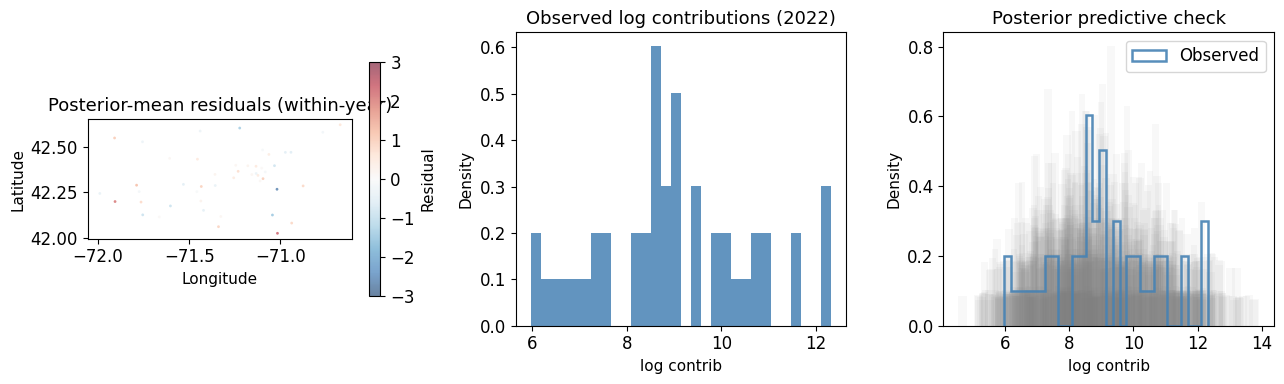

In [13]:
# ── Posterior predictive check — within-year linear model ─────────────────────
# Three panels: residual map | observed histogram | PPC overlay

post = idata_wy_linear.posterior
beta_draws = post['beta'].stack(sample=('chain', 'draw')).values.T   # (S, p)
tau2_draws = post['tau2'].stack(sample=('chain', 'draw')).values     # (S,)

x_raw    = test_df[list(COVARIATES)].astype(float).to_numpy()
x_scaled = (x_raw - wy_linear_data.x_means) / wy_linear_data.x_sds
if wy_linear_data.state_names:
    dummies = pd.get_dummies(test_df['state'], dtype=float).reindex(
        columns=wy_linear_data.state_names, fill_value=0.0
    ).to_numpy()
    X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled, dummies])
else:
    X_test = np.hstack([np.ones((len(test_df), 1)), x_scaled])

y_obs      = test_df['log_contrib_2022'].astype(float).to_numpy()
beta_pm    = beta_draws.mean(axis=0)
resid      = y_obs - (X_test @ beta_pm)

rng   = np.random.default_rng(305)
n_ppc = 200
idx   = rng.choice(beta_draws.shape[0], size=n_ppc, replace=False)
mu_rep    = beta_draws[idx] @ X_test.T                               # (n_ppc, n_test)
sigma_rep = np.sqrt(tau2_draws[idx])[:, None]
y_rep     = rng.normal(mu_rep, sigma_rep)                            # (n_ppc, n_test)

plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 11})
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: residual map
ax = axes[0]
sc = ax.scatter(test_df['lon'], test_df['lat'],
                c=resid, cmap='RdBu_r', vmin=-3, vmax=3,
                s=4, alpha=0.6, linewidths=0)
plt.colorbar(sc, ax=ax, shrink=0.8, label='Residual')
ax.set_title('Posterior-mean residuals (within-year)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_aspect('equal')

# Panel 2: observed histogram
ax = axes[1]
ax.hist(y_obs, bins=30, color='steelblue', alpha=0.85, density=True)
ax.set_title('Observed log contributions (2022)')
ax.set_xlabel('log contrib'); ax.set_ylabel('Density')

# Panel 3: PPC overlay
ax = axes[2]
for i in range(min(50, n_ppc)):
    ax.hist(y_rep[i], bins=30, density=True, alpha=0.05,
            color='gray', histtype='stepfilled')
ax.hist(y_obs, bins=30, density=True, alpha=0.9, color='steelblue',
        histtype='step', linewidth=1.8, label='Observed')
ax.set_title('Posterior predictive check')
ax.set_xlabel('log contrib'); ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('posterior_check_linear_boston.pdf', bbox_inches='tight')
plt.show()

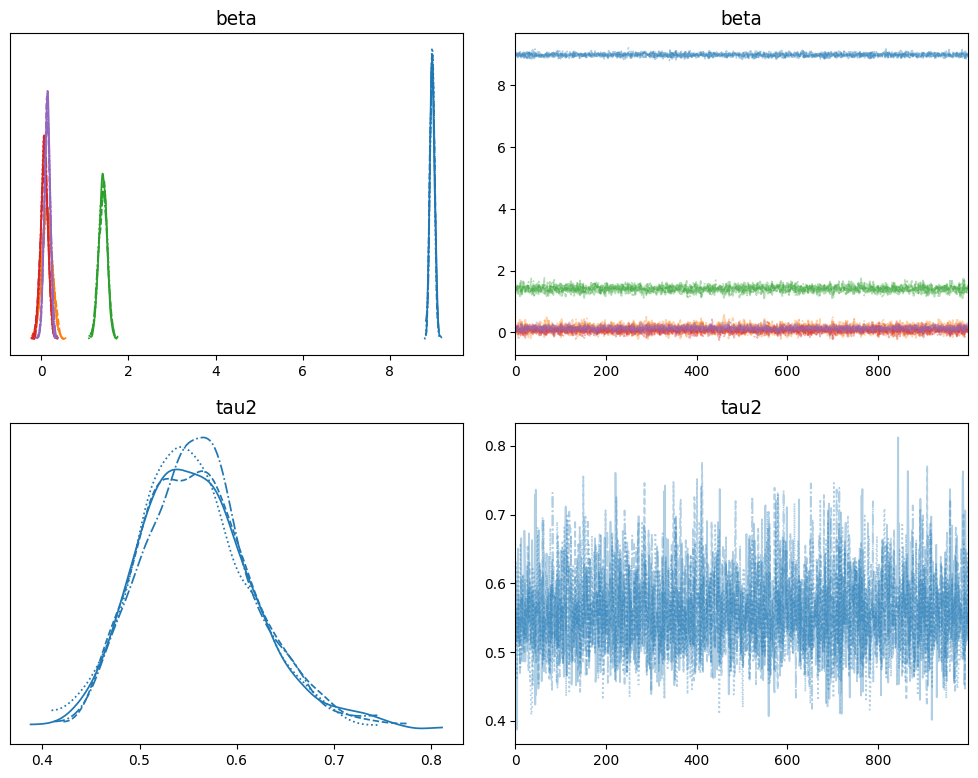

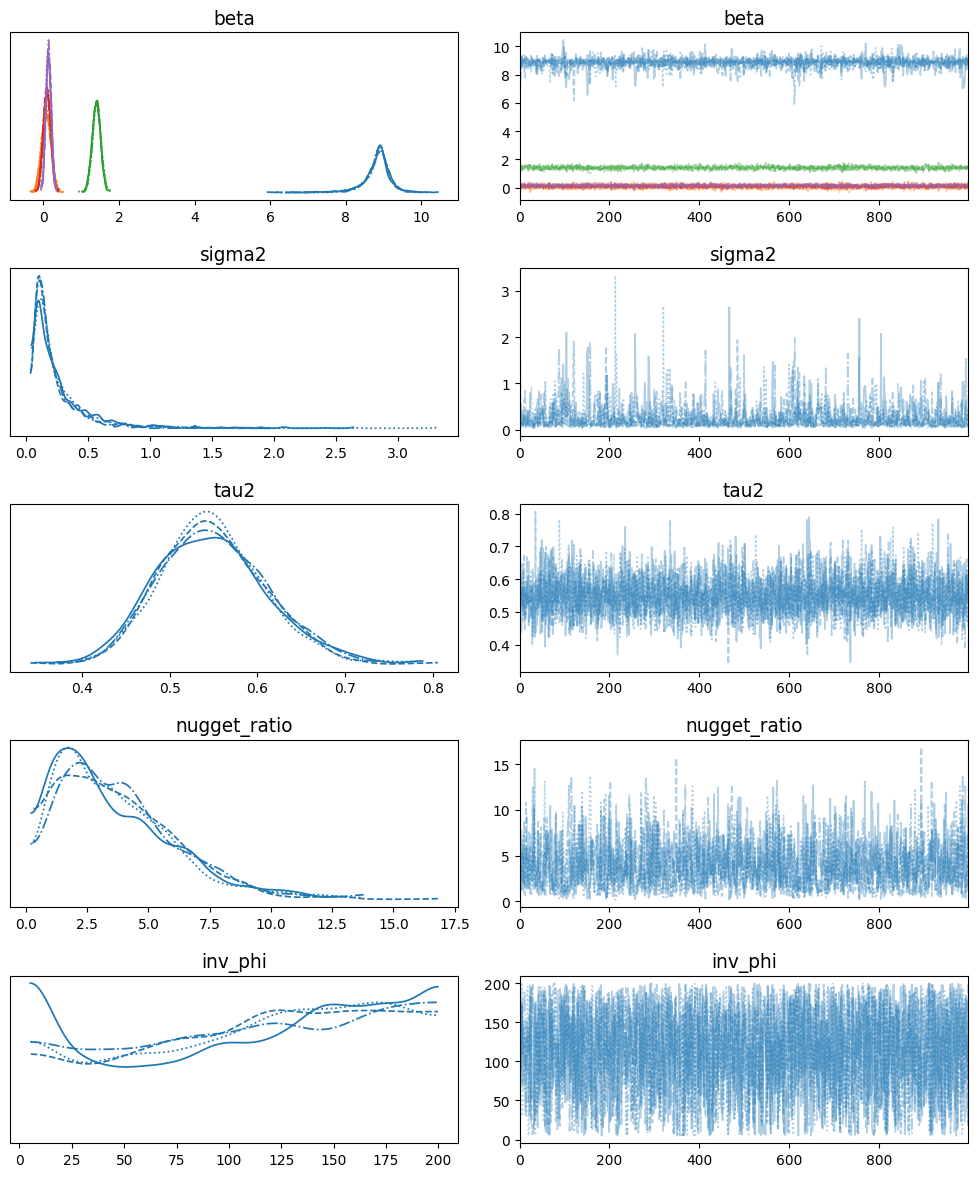

In [15]:
# ── Inference diagnostics ──────────────────────────────────────────────────────
# Trace + marginal posterior plots for key parameters in both models.
# Shows: intercept + 5 continuous covariates + noise/spatial parameters.

def beta_var_and_coords(idata):
    """Return (var_name, coords_dict) for the first 6 beta entries (intercept + 5 covariates)."""
    post = idata.posterior
    if 'beta_cont' in post:
        n = min(6, post['beta_cont'].sizes['beta_cont_dim_0'])
        return 'beta_cont', {'beta_cont_dim_0': list(range(n))}
    else:
        # legacy: single 'beta' variable
        n = min(6, post['beta'].sizes['beta_dim_0'])
        return 'beta', {'beta_dim_0': list(range(n))}

plt.rcParams.update({
    "font.size":        14,   # base size — scales most things
    "axes.titlesize":   16,   # chart title
    "axes.labelsize":   14,   # x/y axis labels
    "xtick.labelsize":  12,   # x tick labels (the model names)
    "ytick.labelsize":  12,   # y tick values
    "legend.fontsize":  12,   # T0/T1/T2/T3 legend
})

# --- Within-year linear ---
bvar, bcoords = beta_var_and_coords(idata_wy_linear)
az.plot_trace(
    idata_wy_linear,
    var_names=[bvar, 'tau2'],
    coords=bcoords,
    compact=True,
    figsize=(10, 8),
)
plt.tight_layout()
plt.savefig('trace_linear_wy.pdf', bbox_inches='tight')
plt.show()

# --- Within-year NNGP ---
bvar, bcoords = beta_var_and_coords(idata_wy_spatial)
az.plot_trace(
    idata_wy_spatial,
    var_names=[bvar, 'sigma2', 'tau2', 'nugget_ratio', 'inv_phi'],
    coords=bcoords,
    compact=True,
    figsize=(10, 12),
)
plt.tight_layout()
plt.savefig('trace_spatial_wy_boston.pdf', bbox_inches='tight')
plt.show()